# Retrieving data & cleaning

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Retrieving AAPL daily close price from 2020-01-01 to 2026-04-27

[*********************100%***********************]  1 of 1 completed

datetime64[ns] <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


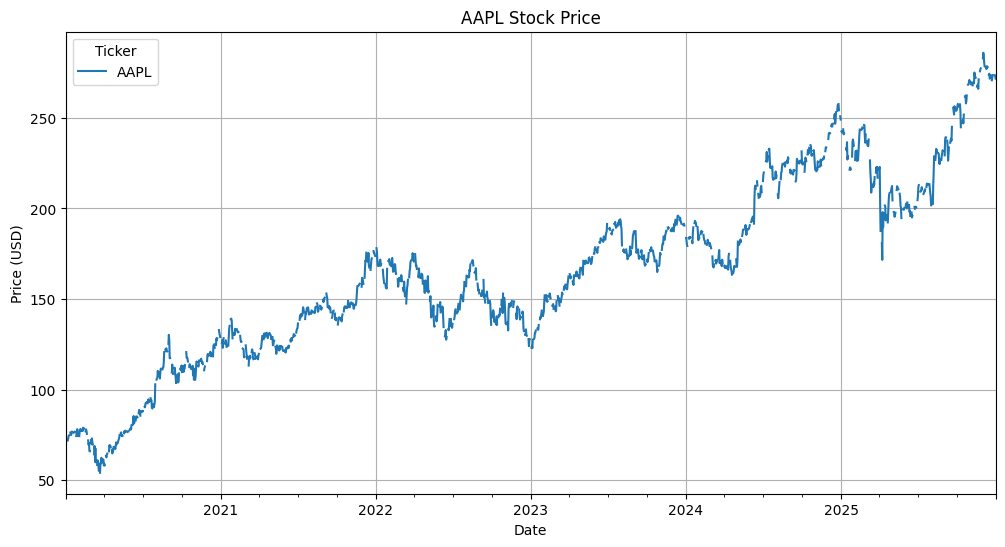

In [2]:

aapl_prices= yf.download("AAPL", start="2020-01-01", end="2026-01-01", auto_adjust=True)['Close'] #autmatically adjust for splits and dividends
aapl_prices = aapl_prices.reindex(pd.date_range(aapl_prices.index.min(), aapl_prices.index.max()))
print(aapl_prices.index.dtype, type(aapl_prices.index))

#displaying the dataframe
aapl_prices.plot(title="AAPL Stock Price", figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid()
plt.show()


In [3]:
#displaying and describing the dataframe
display(aapl_prices)
print(aapl_prices.describe())

#checking for missing values, and assessing when they occur
print(aapl_prices.isna().any(axis=1).groupby(aapl_prices.index.day_name()).sum())

#checking for outliers by looking at the percentage change and filtering for changes greater than 10%
print(aapl_prices.assign(pct_change=aapl_prices['AAPL'].pct_change()).loc[aapl_prices['AAPL'].pct_change().abs() > 0.10])

Ticker,AAPL
2020-01-02,72.400520
2020-01-03,71.696648
2020-01-04,NaN
2020-01-05,NaN
2020-01-06,72.267944
...,...
2025-12-27,NaN
2025-12-28,NaN
2025-12-29,273.504089
2025-12-30,272.824707


Ticker         AAPL
count   1508.000000
mean     164.787444
std       49.672177
min       54.213608
25%      131.299175
50%      163.194351
75%      197.379723
max      285.922455
Friday        11
Monday        32
Saturday     313
Sunday       313
Thursday      10
Tuesday        1
Wednesday      3
dtype: int64
Ticker            AAPL  pct_change
2020-03-13   67.164742    0.119808
2020-03-16   58.524216   -0.128647
2020-03-24   59.652618    0.100326
2020-07-31  102.978691    0.104689
2025-04-09  197.987091    0.153288


/var/folders/04/my9322cd3tl2g_0n77tn28w80000gn/T/ipykernel_42740/206868644.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print(aapl_prices.assign(pct_change=aapl_prices['AAPL'].pct_change()).loc[aapl_prices['AAPL'].pct_change().abs() > 0.10])
/var/folders/04/my9322cd3tl2g_0n77tn28w80000gn/T/ipykernel_42740/206868644.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print(aapl_prices.assign(pct_change=aapl_prices['AAPL'].pct_change()).loc[aapl_prices['AAPL'].pct_change().abs() > 0.10])


In [4]:
import pandas_market_calendars as mcal

# Get actual NYSE trading days in your range
nyse = mcal.get_calendar('NYSE')
trading_days = nyse.valid_days(start_date="2020-01-01", end_date="2026-01-01").tz_localize(None)

# Check which trading days are missing from your downloaded data
missing_trading_days = trading_days.difference(aapl_prices.index)
print(f"Number of truly missing trading days: {len(missing_trading_days)}")
print(missing_trading_days)

ModuleNotFoundError: No module named 'pandas_market_calendars'

In [ ]:
aapl_prices = aapl_prices.dropna()

#### Missing Values & Temporal Alignment
Analysis of the AAPL time series reveals that missing data points predominantly coincide with weekends (91.65% of missing values) and scheduled market holidays (8.34% of missing values). We recorded an average of 113.83 missing days per year, which aligns closely with the expected 115 annual non-trading days.

To ensure the integrity of the path-dependent Asian pricer, we have opted to remove these gaps rather than interpolate them. All subsequent mathematical computations, including volatility and the binomial tree's time-step Δt, will be based on a standard 252-day trading year.

#### Extreme Volatility Events
We identified five specific dates where AAPL’s daily returns exceeded a ±10% threshold. Each event was audited to determine if it represented a "fat-finger" data error or legitimate market risk. Our findings confirm these are valid historical events:

**2020-03-13** (+11.98% daily gain): This was amid the COVID-19-induced 2020 stock market crash.  U.S. markets rallied sharply, with the Dow Jones, NASDAQ, and S&P 500 each rising over 9% in their largest single-day gains since 2008, following prior circuit breaker halts. Apple followed this trend with a strong rebound from pandemic fears and oil price collapses

**2020-03-16** (-12.86% daily loss): Apple dropped sharply alongside broader sell-offs from escalating COVID-19 lockdowns, economic shutdowns

**2020-03-24** ( +10.03% daily gain): Continued volatility from the crash, but markets began stabilizing. Apple rebounded as investors anticipated stimulus and saw tech resilience amid remote work shifts, though still down from pre-crash peaks. This fit the the crash end phase. 

**2020-07-31** (+10.47% daily gain):  Apple surged on blowout quarterly earnings, beating expectations with $59.7 billion revenue (up 11% YoY) driven by iPhone, Services, and Mac sales amid pandemic demand. And the stock split announcement 4-1 boosted sentiment. 

**2025-04-09** (+15.33% daily gain): This is driven by investor optimism following a temporary reprieve from severe, recently announced trade tariffs. The stock recovered from one of its worst four-day stretches since 2000. 


In [ ]:
#calculating log returns and extracting the column into a separate series, dropping the first value which is NaN due to the shift
aapl_prices['log return'] = np.log(aapl_prices['AAPL'] / aapl_prices['AAPL'].shift(1))
aapl_log_return = aapl_prices['log return'].dropna()
